## Plot the E1's

In [78]:
# Load the files back as the same dict to be able to start from here next time

import pandas as pd
import numpy as np

eig_dict = {}
resolutions = [10_000, 50_000, 100_000]

for resolution in resolutions:
    eig_dict[resolution] = {}
    eig_dict[resolution]['X'] = pd.read_csv(
        f"../data/eigs/sperm_X.chr8.eigs.{resolution}.arms.cis.vecs.tsv",
        sep="\t"
    )
    eig_dict[resolution]['Y'] = pd.read_csv(
        f"../data/eigs/sperm_Y.chr8.eigs.{resolution}.arms.cis.vecs.tsv",
        sep="\t"
    )



In [79]:
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('smaller.mplstyle')

import numpy as np


from scipy.stats import norm

def plot_e1_distribution(df, e1_column='E1', start_column='start', bins=51, title=None):
    """
    Plots the histogram and normal distributions of E1 values for A and B compartments.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        e1_column (str): Column name for E1 values.
        start_column (str): Column name for start positions (optional, not used in the plot).
        bins (int): Number of bins for the histogram.
    """
    x = df[start_column].values
    y = df[e1_column].values

    f, ax = plt.subplots()
    xmin, xmax = ax.set_xlim(-2,2)
    bins = np.linspace(xmin, xmax, bins)

    # A compartments
    ax.hist(y[y > 0], bins=bins, color="tab:red", alpha=0.5, label="A", )
    # B compartments
    ax.hist(y[y < 0], bins=bins, color="tab:blue", alpha=0.5, label="B",)
    # Mean values (vline)
    ax.axvline(y[y > 0].mean(), color="tab:red", linestyle="--", label="Mean A")
    ax.axvline(y[y < 0].mean(), color="tab:blue", linestyle="--", label="Mean B")

    # # Plot the normal distributions
    # x_values = np.linspace(y.min(), y.max(), 1000)
    # mean_a = np.median(y[y > 0])
    # mean_b = np.median(y[y < 0])
    # std_a = y[y > 0].std()
    # std_b = y[y < 0].std()

    # ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
    # ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
    # stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
    # ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

    # Final touches
    plt.xlabel("E1")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


# Plot the E1 tracks saved in a dict

def plot_eigenvectors(df, title=None, scatter=True, scatter_alpha=0.5):
    fig, ax = plt.subplots(figsize=(6, 1))

    x = df['start']
    y = df['E1']

    # # Make stairs
    # x_stairs = np.zeros(2* len(x))
    # x_stairs[::2] = x
    # x_stairs[1::2] = x + resolution
    # y_stairs = np.zeros(2* len(y))
    # y_stairs[::2] = y
    # y_stairs[1::2] = y


    if scatter:
        ax.scatter(x, y, s=0.4, color='k', alpha=scatter_alpha, ec='None')
    ax.fill_between(x, y, where = y<0, color='tab:blue', lw=1, ec='None', step='post', interpolate=True)
    ax.fill_between(x, y, where = y>0, color='tab:red', lw=1, ec='None', step='post', interpolate=True) 
    ax.set_title(title)
    ax.set_ylabel('E1')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(-1,1)
    ax.set_xlabel('Genomic Position (Mbp)')
    ticks = np.arange(0, x.max(), step=100*resolution)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{int(t/1e6)}' for t in ticks])
    ax.spines[:].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    plt.tight_layout()
    plt.show()




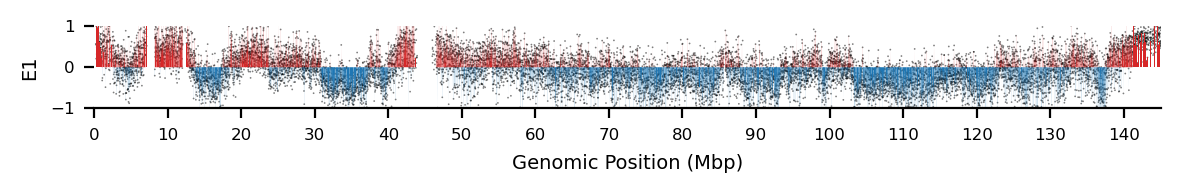

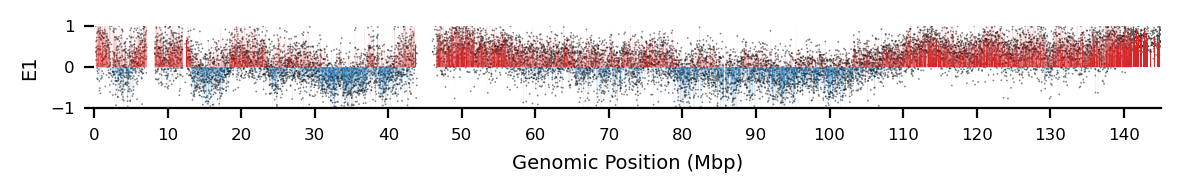

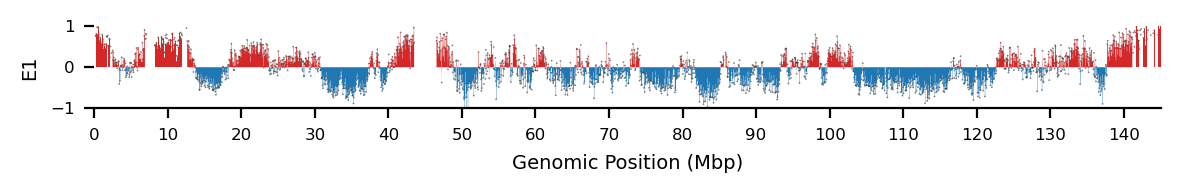

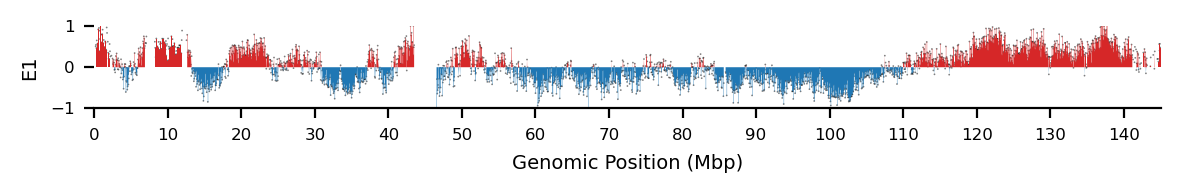

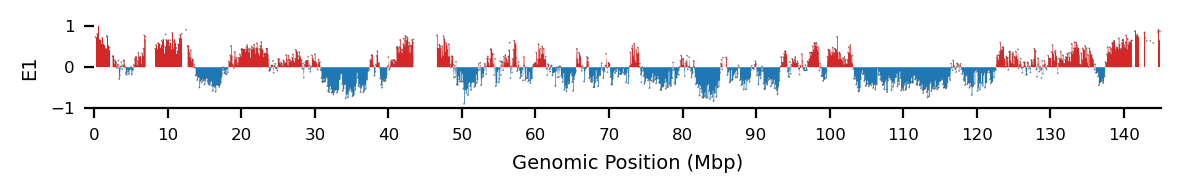

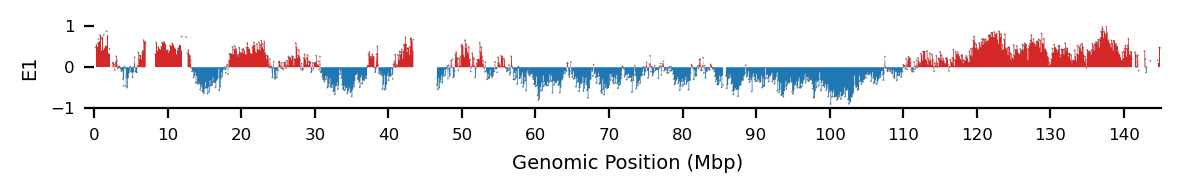

In [80]:
#| echo: false
#| label: fig-chr8-eigs
#| fig-cap: "Comparing the eigenvector E1 for chr8 in X- and Y-bearing sperm at different resolutions. Here, the eigenvectors are re-sorted by their Spearman correlation with the GC content."
#| fig-scap: "Compare chr8 E1 for X/Y-bearing sperm"
#| fig-subcap:
#|  - "E1 for X-bearing sperm (10kb)"
#|  - "E1 for Y-bearing sperm (10kb)"
#|  - "E1 for X-bearing sperm (50kb)"
#|  - "E1 for Y-bearing sperm (50kb)"
#|  - "E1 for X-bearing sperm (100kb)"
#|  - "E1 for Y-bearing sperm (100kb)"
#| layout-ncol: 1


for res, dict in eig_dict.items():
    df_e1_x = dict['X']
    df_e1_y = dict['Y']
    
    plot_eigenvectors(df_e1_x, title=None)

    
    plot_eigenvectors(df_e1_y, title=None)


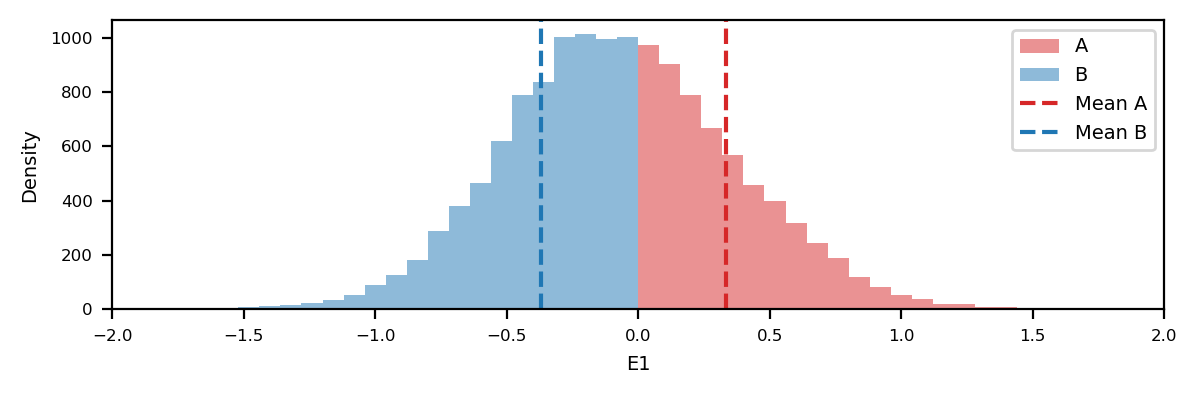

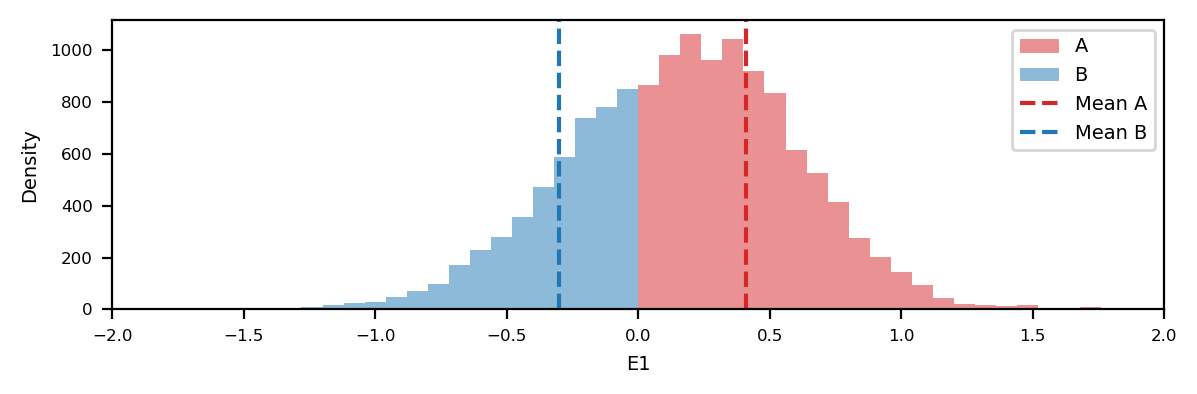

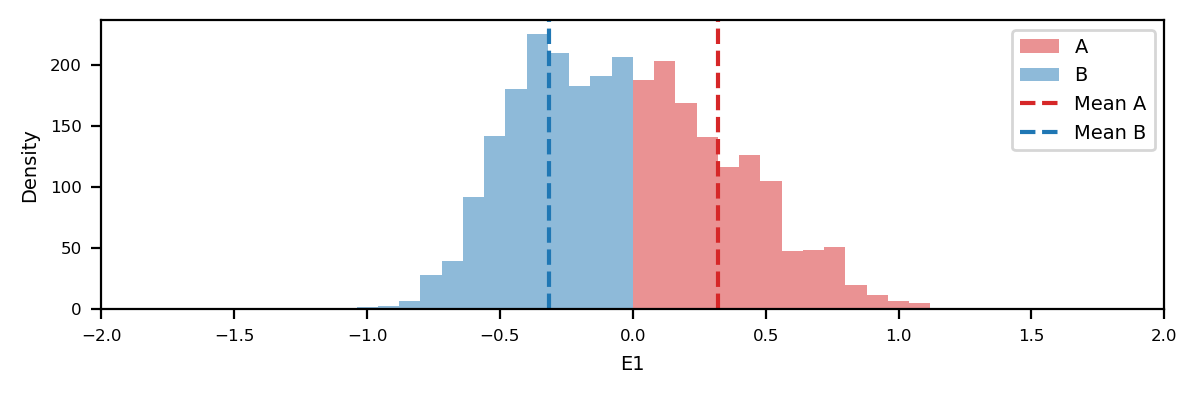

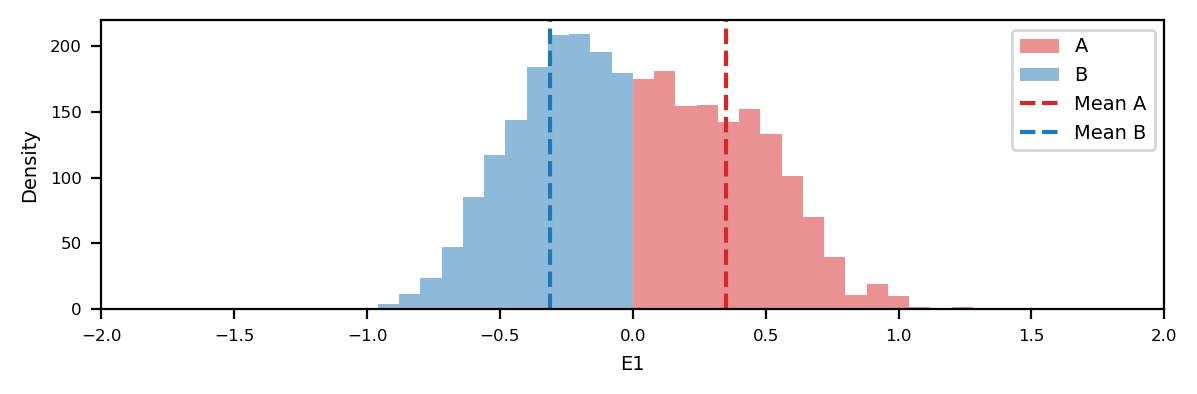

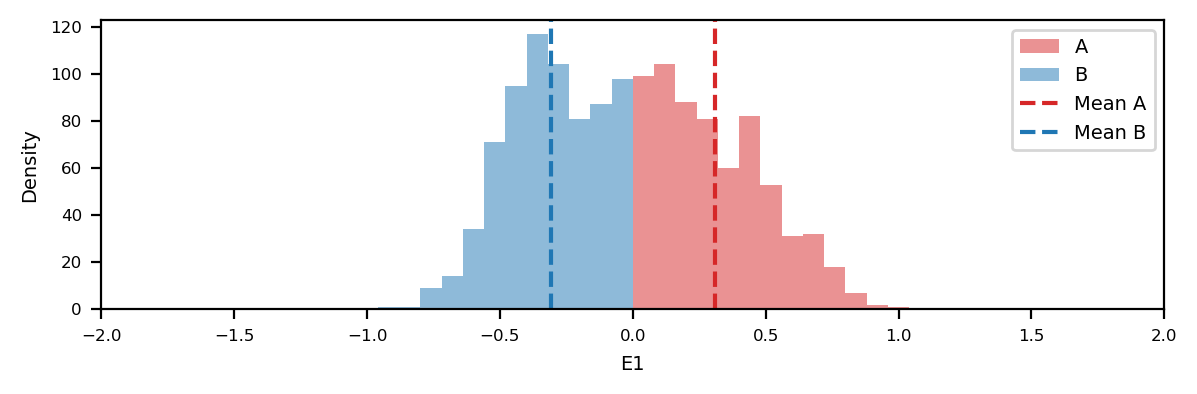

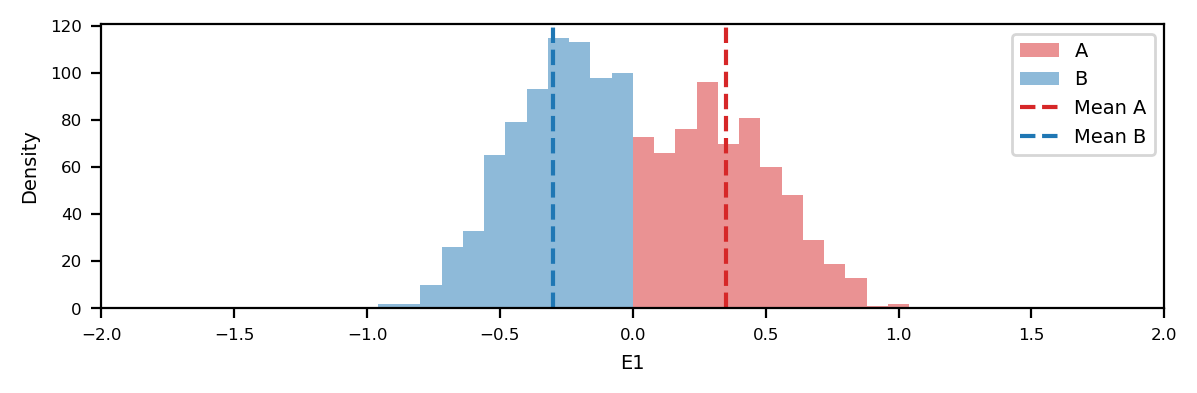

In [81]:

for res, dict in eig_dict.items():
    df_e1_x = dict['X']
    df_e1_y = dict['Y']
    
    plot_e1_distribution(df_e1_x, title=None)
    plot_e1_distribution(df_e1_y, title=None)

## Load back the traces

To be able to start from here

In [12]:
import arviz as az
import numpy as np

In [13]:
# Decide resolution to load 
resolution = 10_000  
resname = f"{resolution//1000}kb"

trace_dir = "../results/traces/"
chr8_x_NNHN_path = f"{trace_dir}/12.chr8.{resname}.X.mix.arms.trace.nc"
chr8_y_NNHN_path = f"{trace_dir}/12.chr8.{resname}.Y.mix.arms.trace.nc"
chr8_x_NTHN_path = f"{trace_dir}/12.chr8.{resname}.X.NTHN.mix.arms.trace.nc"
chr8_y_NTHN_path = f"{trace_dir}/12.chr8.{resname}.Y.NTHN.mix.arms.trace.nc"



traces = {f'{resname}.X.NNHN': az.from_netcdf(chr8_x_NNHN_path),
          f'{resname}.Y.NNHN': az.from_netcdf(chr8_y_NNHN_path),
          f'{resname}.X.NTHN': az.from_netcdf(chr8_x_NTHN_path),
          f'{resname}.Y.NTHN': az.from_netcdf(chr8_y_NTHN_path)}

traces[f'{resname}.X.NNHN']

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [14]:
display(
    az.summary(traces[f'{resname}.X.NNHN'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces[f'{resname}.Y.NNHN'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces[f'{resname}.X.NTHN'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces[f'{resname}.Y.NTHN'], var_names=["mu", "sigma", "grw_sigma"]),
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.293,0.005,-0.304,-0.283,0.0,0.0,7059.0,5762.0,1.0
mu[A],0.321,0.008,0.306,0.336,0.0,0.0,7806.0,5692.0,1.0
sigma[B],0.327,0.003,0.322,0.333,0.0,0.0,8136.0,5767.0,1.0
sigma[A],0.325,0.004,0.318,0.332,0.0,0.0,7277.0,4928.0,1.0
grw_sigma,0.080,0.003,0.075,0.086,0.0,0.0,7148.0,4999.0,1.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],0.006,0.165,-0.147,0.203,0.062,0.009,11.0,142.0,1.68
mu[A],0.332,0.118,0.189,0.442,0.044,0.006,11.0,142.0,1.68
sigma[B],0.328,0.010,0.310,0.341,0.003,0.001,11.0,135.0,1.65
sigma[A],0.406,0.108,0.307,0.540,0.041,0.006,11.0,150.0,1.68
grw_sigma,0.057,0.006,0.046,0.066,0.002,0.000,11.0,132.0,1.65


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.221,0.089,-0.307,-0.112,0.034,0.005,11.0,145.0,1.69
mu[A],0.122,0.208,-0.126,0.313,0.078,0.011,11.0,130.0,1.68
sigma[B],0.479,0.174,0.322,0.695,0.065,0.010,11.0,157.0,1.69
sigma[A],0.343,0.013,0.327,0.363,0.005,0.001,11.0,139.0,1.68
grw_sigma,0.306,0.039,0.244,0.384,0.010,0.002,18.0,130.0,1.31


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.137,0.006,-0.149,-0.126,0.0,0.0,6250.0,5986.0,1.0
mu[A],0.427,0.005,0.417,0.437,0.0,0.0,7983.0,6191.0,1.0
sigma[B],0.338,0.004,0.332,0.345,0.0,0.0,9949.0,5845.0,1.0
sigma[A],0.317,0.003,0.311,0.323,0.0,0.0,8515.0,5559.0,1.0
grw_sigma,0.182,0.018,0.148,0.215,0.0,0.0,2775.0,3938.0,1.0


In [15]:
# get the w variable and stack for each model

w_vars = {name: trace.posterior.w.stack(sample=('chain', 'draw')) for name, trace in traces.items()}

for key,w in w_vars.items():
    print(f"Model: {key}")
    display(w)

Model: 10kb.X.NNHN


<xarray.DataArray 'w' (pos: 13841, sample: 7000)> Size: 775MB
array([[0.55695377, 0.49817932, 0.53362606, ..., 0.51705926, 0.52172189,
        0.53474042],
       [0.54651554, 0.51556538, 0.58975761, ..., 0.48967624, 0.49194066,
        0.58102442],
       [0.56295908, 0.5494001 , 0.62182497, ..., 0.53204272, 0.53716797,
        0.56587486],
       ...,
       [0.99989203, 0.99106255, 0.9993526 , ..., 0.99807747, 0.99942434,
        0.99875594],
       [0.99988448, 0.9908002 , 0.99934231, ..., 0.99790145, 0.99936686,
        0.99878875],
       [0.99988719, 0.99125599, 0.99928624, ..., 0.99803523, 0.99937519,
        0.99867027]], shape=(13841, 7000))
Coordinates:
  * pos      (pos) int64 111kB 210000 220000 230000 ... 145050000 145060000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 10kb.Y.NNHN


<xarray.DataArray 'w' (pos: 13839, sample: 7000)> Size: 775MB
array([[0.53386527, 0.48957473, 0.51151567, ..., 0.52418946, 0.49115558,
        0.52374612],
       [0.54716117, 0.48886591, 0.54436929, ..., 0.5269982 , 0.49894936,
        0.52678663],
       [0.54992248, 0.52007089, 0.52004585, ..., 0.52475705, 0.51135775,
        0.52307119],
       ...,
       [0.99969409, 0.999093  , 0.99764557, ..., 0.98865389, 0.97193969,
        0.99600287],
       [0.99970848, 0.99902814, 0.99784188, ..., 0.98974823, 0.97037888,
        0.99626259],
       [0.99969688, 0.99905783, 0.99781272, ..., 0.98975501, 0.97031389,
        0.9962842 ]], shape=(13839, 7000))
Coordinates:
  * pos      (pos) int64 111kB 210000 220000 230000 ... 145050000 145060000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 10kb.X.NTHN


<xarray.DataArray 'w' (pos: 13841, sample: 7000)> Size: 775MB
array([[6.76137384e-01, 7.28217952e-01, 7.39193176e-01, ...,
        4.10784342e-01, 5.18070391e-01, 4.31357080e-01],
       [6.49434568e-01, 7.97341010e-01, 7.99888875e-01, ...,
        3.98512397e-01, 4.20795560e-01, 4.26622023e-01],
       [5.95253869e-01, 8.35927623e-01, 8.22521026e-01, ...,
        3.38262228e-01, 4.13173910e-01, 3.91560574e-01],
       ...,
       [9.99971774e-01, 9.99998726e-01, 9.99985244e-01, ...,
        2.30591478e-02, 3.68053732e-06, 1.31969013e-06],
       [9.99969742e-01, 9.99998772e-01, 9.99987540e-01, ...,
        2.61154964e-02, 3.78765006e-06, 1.88396088e-06],
       [9.99946094e-01, 9.99998803e-01, 9.99989476e-01, ...,
        3.15261557e-02, 3.83190613e-06, 3.46121854e-06]],
      shape=(13841, 7000))
Coordinates:
  * pos      (pos) int64 111kB 210000 220000 230000 ... 145050000 145060000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 10kb.Y.NTHN


<xarray.DataArray 'w' (pos: 13839, sample: 7000)> Size: 775MB
array([[0.56152893, 0.49348244, 0.5603021 , ..., 0.54208151, 0.59413077,
        0.51174568],
       [0.63293136, 0.48738296, 0.6124696 , ..., 0.62850594, 0.65728232,
        0.54797534],
       [0.64834192, 0.45556894, 0.66860213, ..., 0.66482314, 0.6964062 ,
        0.57139052],
       ...,
       [1.        , 0.99998978, 0.99995955, ..., 1.        , 0.99999985,
        0.99998538],
       [1.        , 0.99998639, 0.99995419, ..., 1.        , 0.99999985,
        0.99998651],
       [1.        , 0.99998645, 0.99994587, ..., 1.        , 0.99999982,
        0.9999849 ]], shape=(13839, 7000))
Coordinates:
  * pos      (pos) int64 111kB 210000 220000 230000 ... 145050000 145060000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [16]:
import matplotlib.pyplot as plt
import arviz as az
plt.style.use('smaller.mplstyle')

def plot_traces_and_energy(traces, trace_keys=None, var_names=['mu', 'sigma', 'grw_sigma'], figsize=(6, 4), layout='tight'):
    """
    Plot traces and energy plots for specified keys in the traces dictionary.

    Parameters:
        traces (dict): Dictionary containing ArviZ trace objects.
        trace_keys (list): List of keys in the traces dictionary to plot.
        var_names (list): List of variable names to include in the trace plots.
        figsize (tuple): Figure size for the subplots.
        layout (str): Layout option for the plots (e.g., 'tight').
    """
    if trace_keys is None:
        trace_keys = list(traces.keys())

    for key in trace_keys:
        # Plot trace
        f, axs = plt.subplots(3, 2, figsize=figsize, layout=layout)
        az.plot_trace(
            traces[key],
            var_names=var_names,
            compact=True,
            axes=axs,
            trace_kwargs={'linewidth': 0.3, 'alpha': 0.5},
            plot_kwargs={'alpha': 0.5, 'linewidth': 0.5}
        )
        for ax in axs.ravel():
            ax.title.set_fontsize(8)
            ax.xaxis.label.set_size(7)
            ax.yaxis.label.set_size(7)
            ax.tick_params(labelsize=6)

        plt.suptitle(f'Trace plots for {key}', fontsize=10)

    # Make a grid of energy plots
    ncols = 2
    nrows = int(np.ceil(len(trace_keys) / ncols))
    f, axs = plt.subplots(ncols, nrows, figsize=(6, 2*nrows), layout=layout)
    axs = axs.ravel()
    for i,key in enumerate(trace_keys):
        ax = axs[i]
        ax.set_title(f'Energy plot for {key}')
        az.plot_energy(traces[key], backend_kwargs={'layout': layout}, ax=ax)

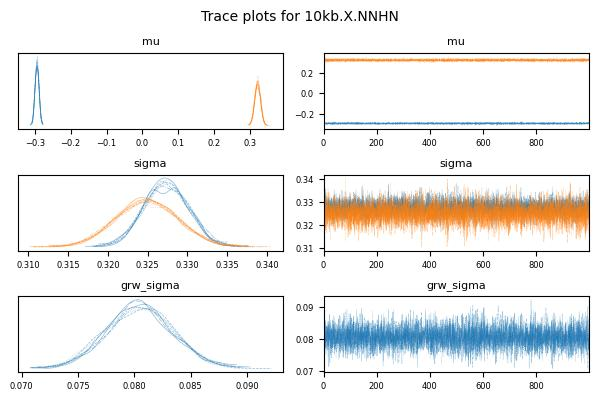

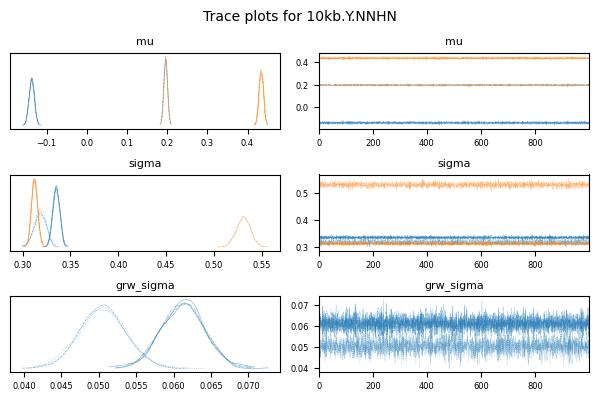

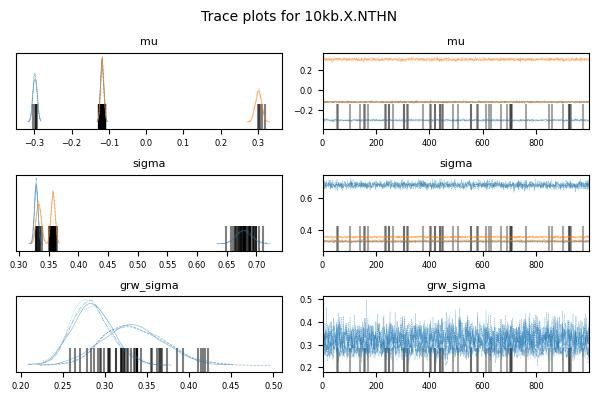

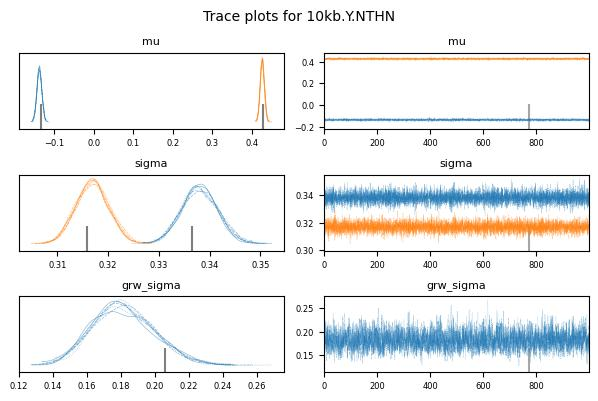

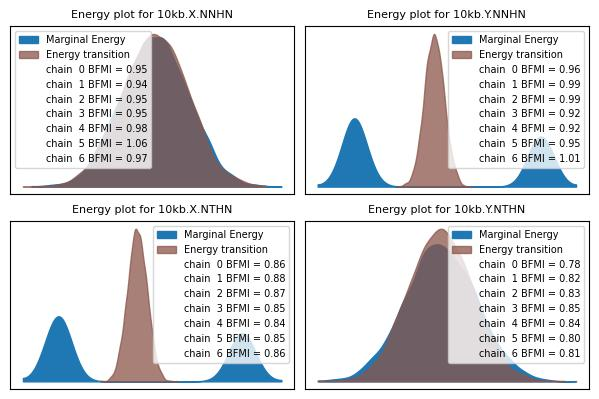

In [17]:
plot_traces_and_energy(traces)

array([[<Axes: title={'center': 'mu\nB'}>,
        <Axes: title={'center': 'mu\nB'}>],
       [<Axes: title={'center': 'mu\nA'}>,
        <Axes: title={'center': 'mu\nA'}>]], dtype=object)

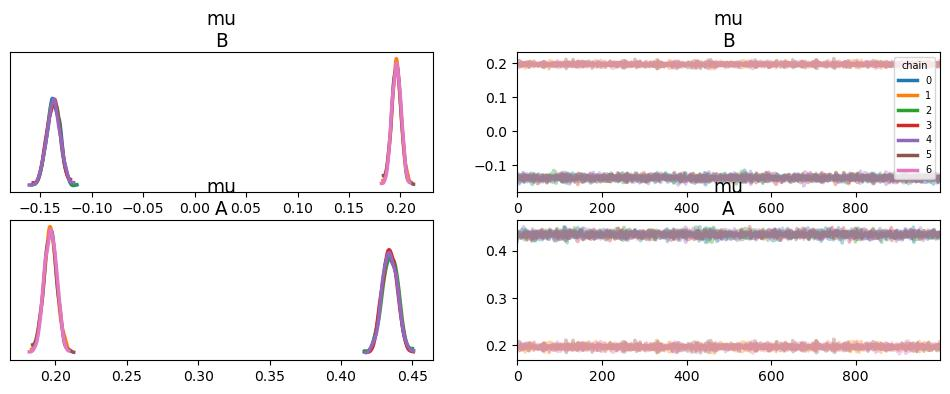

In [18]:
import matplotlib.pyplot as plt
tmp_trace = traces[f'{resname}.Y.NNHN']
az.plot_trace(tmp_trace, var_names=["mu"], compact=False, legend=True)

Model: 10kb.X.NNHN, non-empty bins: 13841


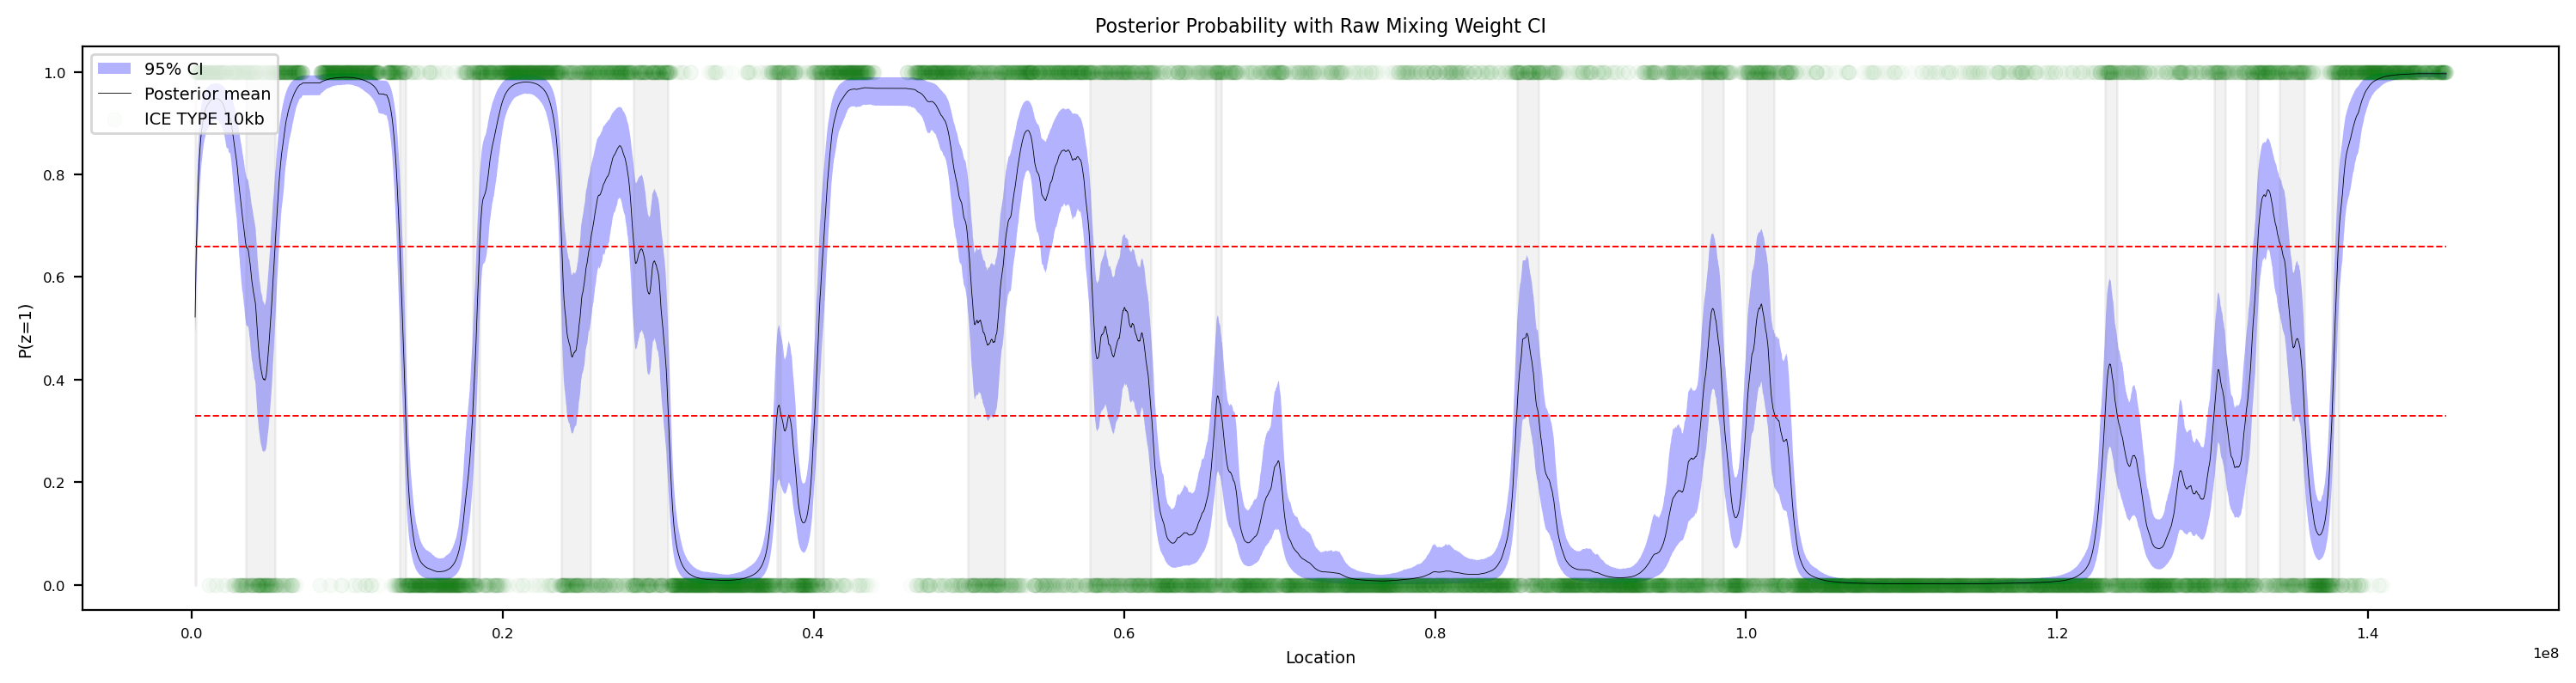

Model: 10kb.Y.NNHN, non-empty bins: 13839


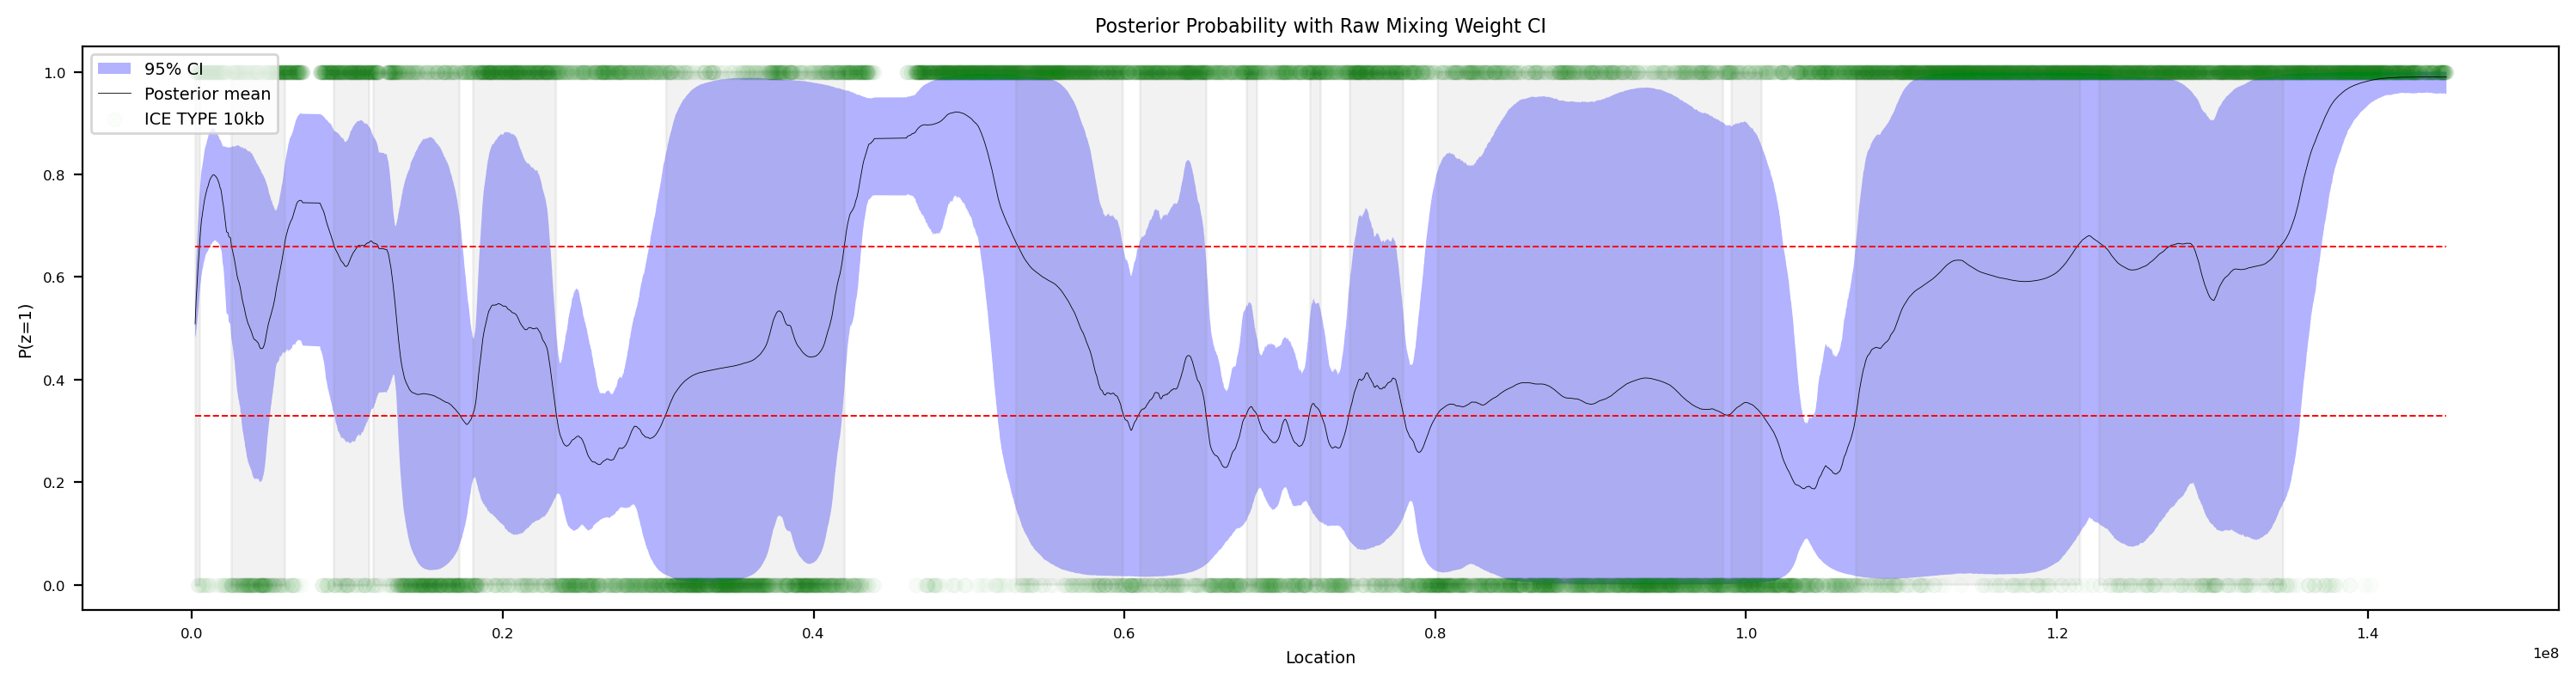

Model: 10kb.X.NTHN, non-empty bins: 13841


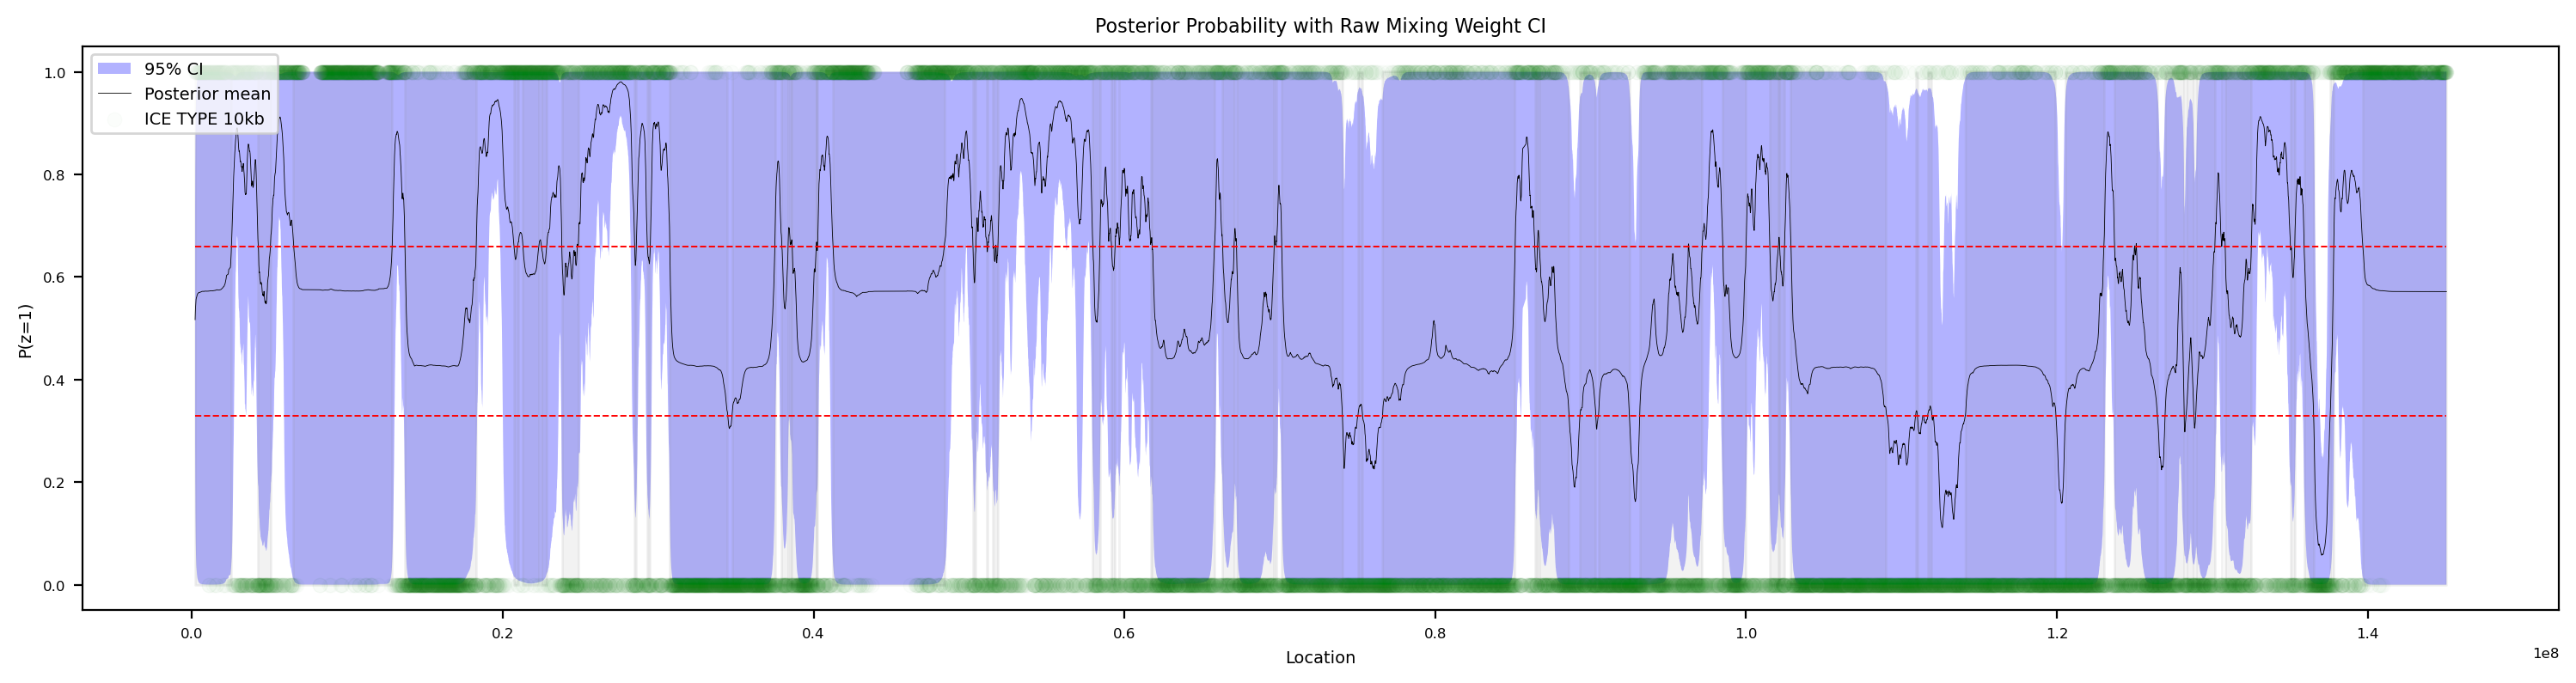

Model: 10kb.Y.NTHN, non-empty bins: 13839


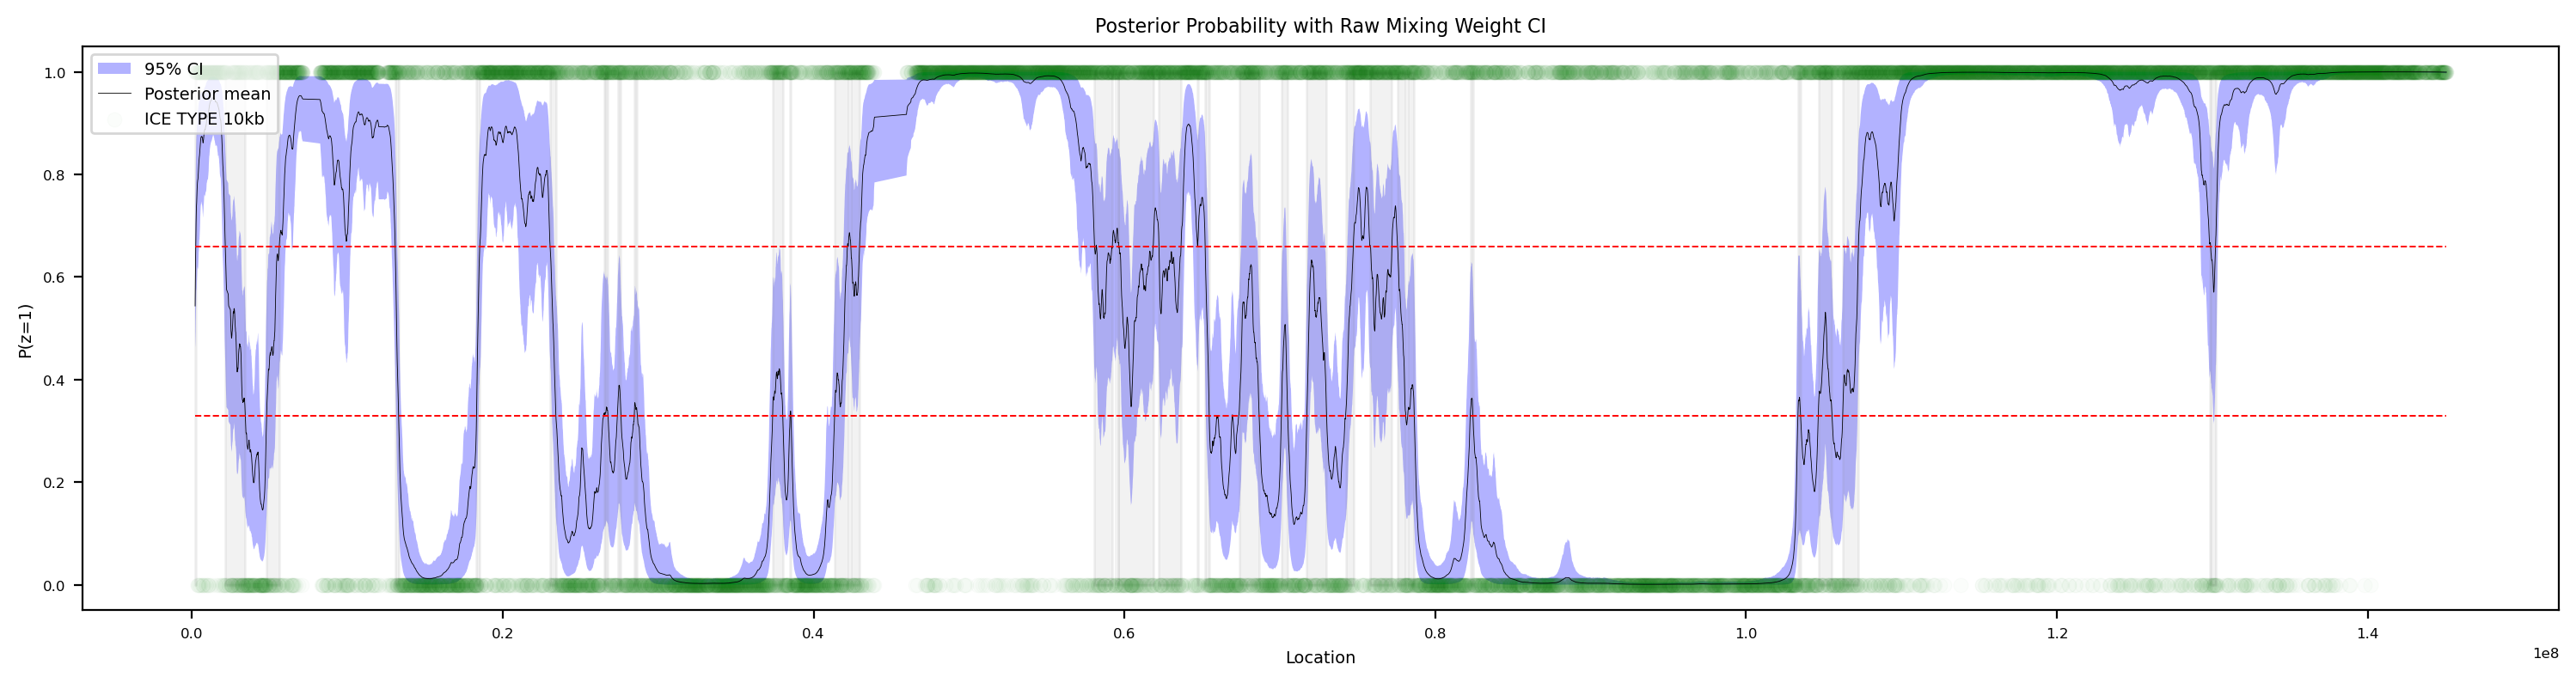

In [19]:
import matplotlib.pyplot as plt

# Set matplotlib to display retina format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

for name, w_stack in w_vars.items():
    print(f"Model: {name}, non-empty bins: {w_stack.pos.size}")   
    w_mean = w_stack.mean(dim=('sample'))
    w_ci_direct = w_stack.quantile([0.05, 0.95], dim=("sample"))
    w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)
    w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)

    x = w_stack["pos"]

    f, ax = plt.subplots(figsize=(15, 4))

    ax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        label="95% CI",
        color="blue",
        ec='None'
    )

    x_grey = x.copy()
    x_grey = x_grey.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    # Grey band
    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray')

    # # Compare e1 predictions
    e1 = traces[name].observed_data.y_hat.values
    hard_assign =  e1 > 0

    ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

    ax.scatter(x, hard_assign, label="ICE TYPE 10kb", color="green", linewidth=0.5, alpha=0.015)

    # Plot the 0.5 line
    ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.7)

    plt.ylabel("P(z=1)")
    plt.xlabel("Location")
    plt.legend(loc='upper left')
    plt.title("Posterior Probability with Raw Mixing Weight CI")
    plt.tight_layout()
    plt.show()




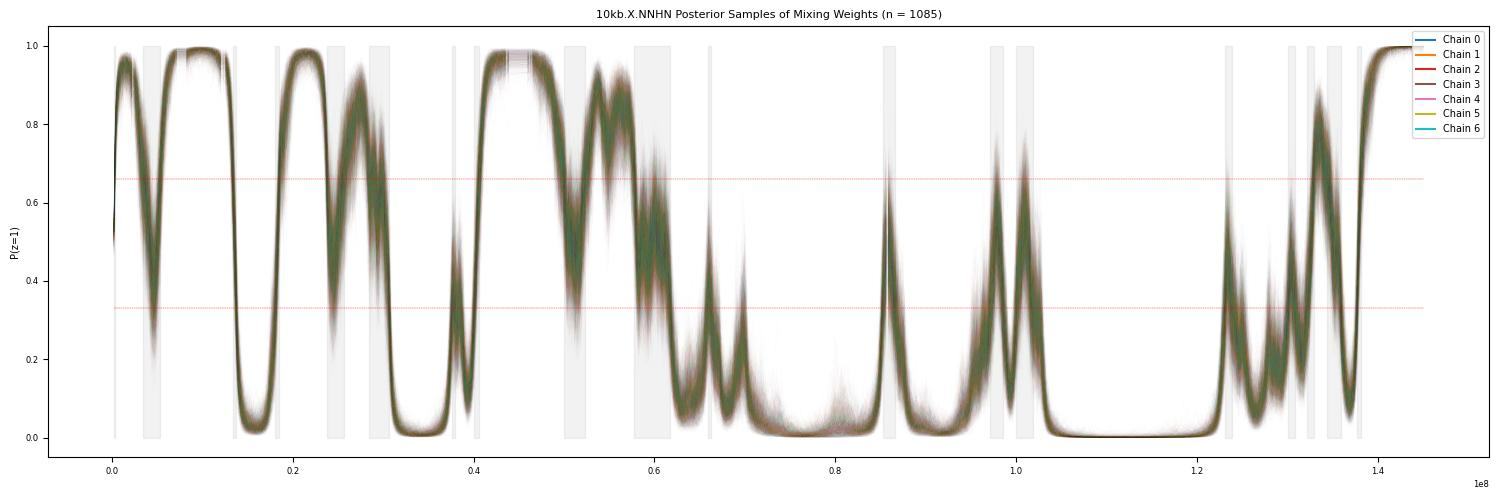

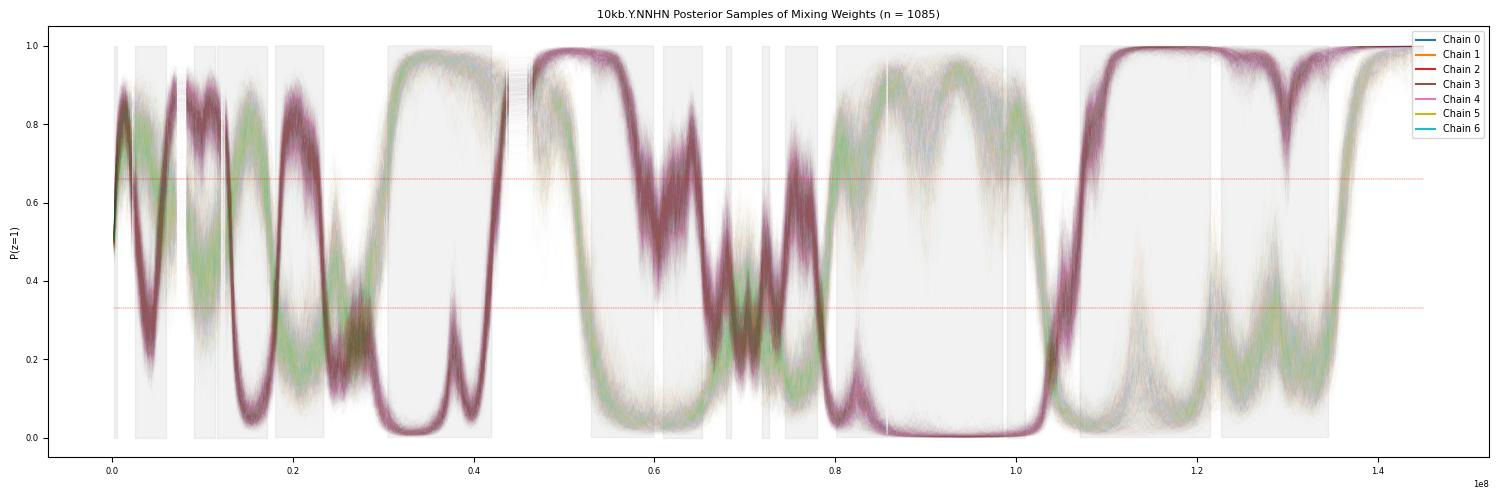

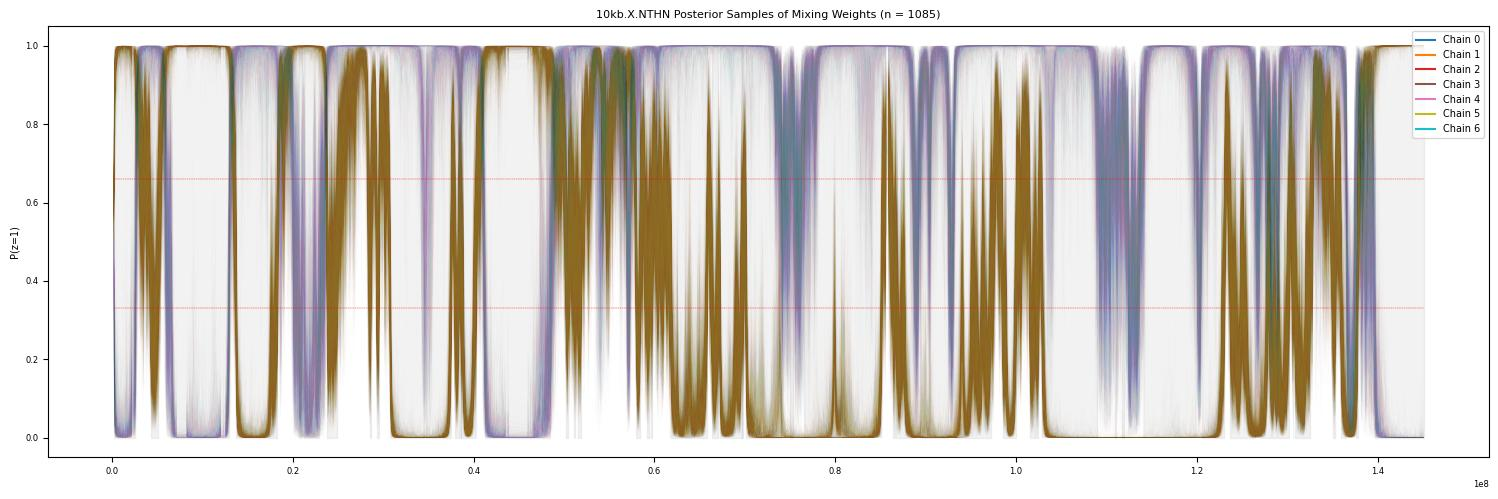

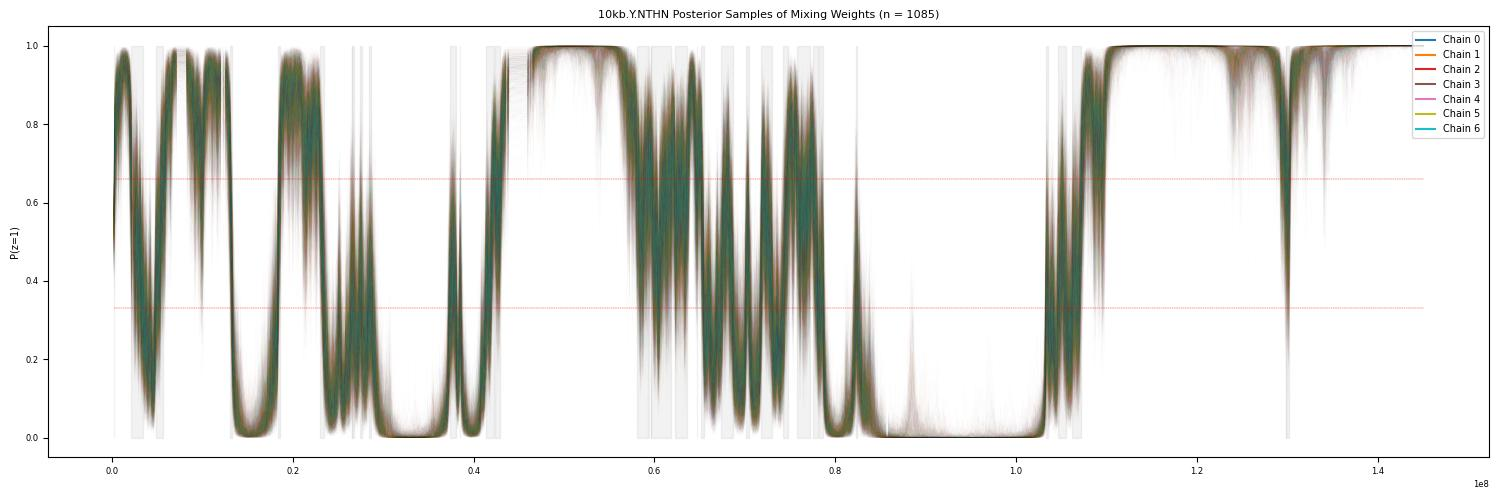

In [21]:
# Plot the all posterior samples of `w` in a single plot
# but start out with a smaller subset
# set the inline display to low dpi
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')
import matplotlib.lines as mlines

for name, w_stack in w_vars.items():
    x = w_stack["pos"]
    w_mean = w_stack.mean(dim=('sample'))
    total_points = 15_000_000
    n_curves = total_points // len(x)
    n_chains = np.unique(w_stack.chain).shape[0]
    # Subset ncurves // nchains from each chain
    w_subset = w_stack.sel(draw=slice(0,n_curves//n_chains))

    # Example: chain colors
    unique_chains = np.unique(w_subset.chain)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_chains)))
    chain_to_color = {c: colors[i] for i, c in enumerate(unique_chains)}

    fig, ax = plt.subplots(figsize=(15,5))

    # Plot lines with alpha < 1
    for chain_id in unique_chains:
        cols = np.where(w_subset.chain == chain_id)[0]
        for i in cols:
            ax.plot(x, w_subset[:, i], color=chain_to_color[chain_id], alpha=0.05, linewidth=0.05)

    # Create custom legend handles with alpha=1
    handles = [mlines.Line2D([], [], color=chain_to_color[c], label=f'Chain {c}', alpha=1) 
            for c in unique_chains]

    ax.legend(handles=handles, loc="upper right")

    # Grey band

    x_grey = x.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray')

    ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    ax.set_ylabel("P(z=1)")

    plt.title(f"{name} Posterior Samples of Mixing Weights (n = {w_subset.shape[1]})")
    plt.tight_layout()
    plt.show()



## Count the transitions

Start with just one trace

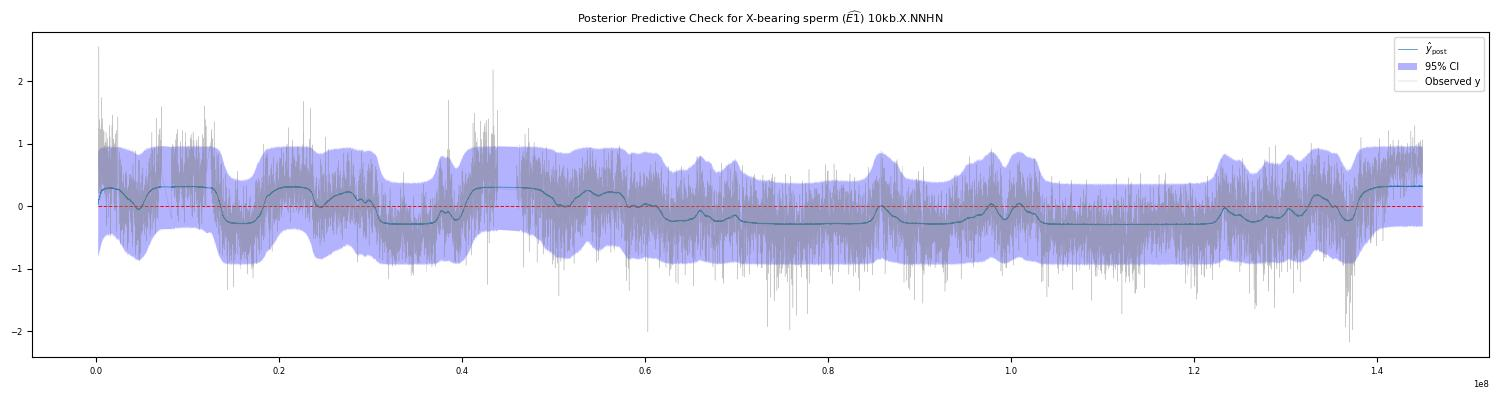

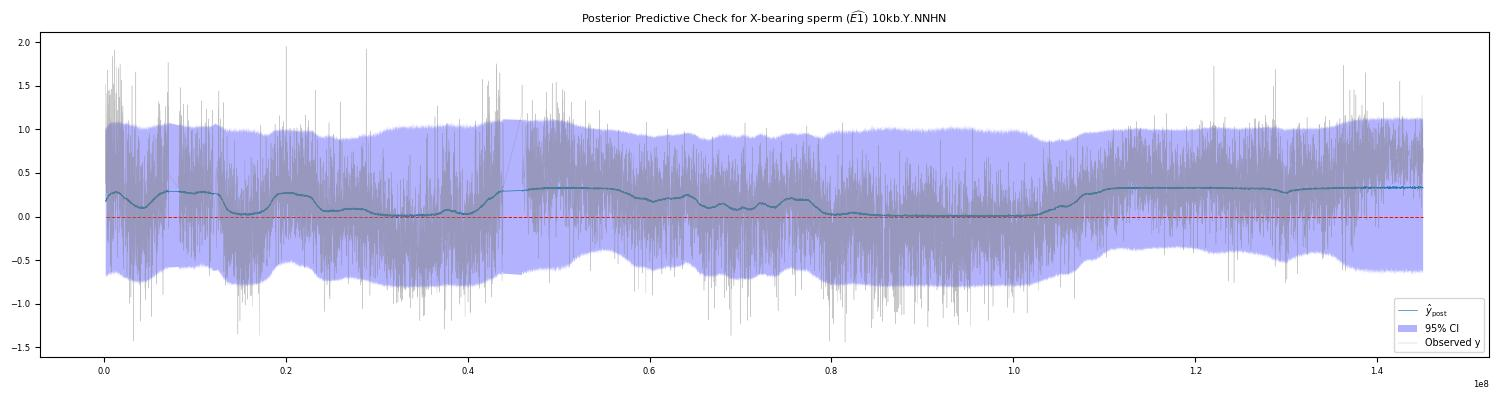

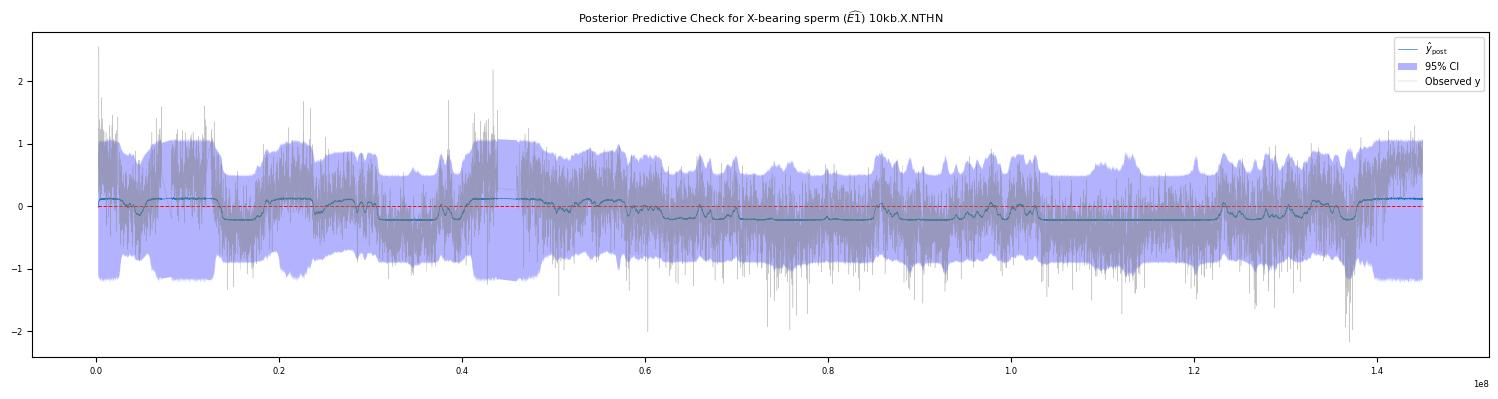

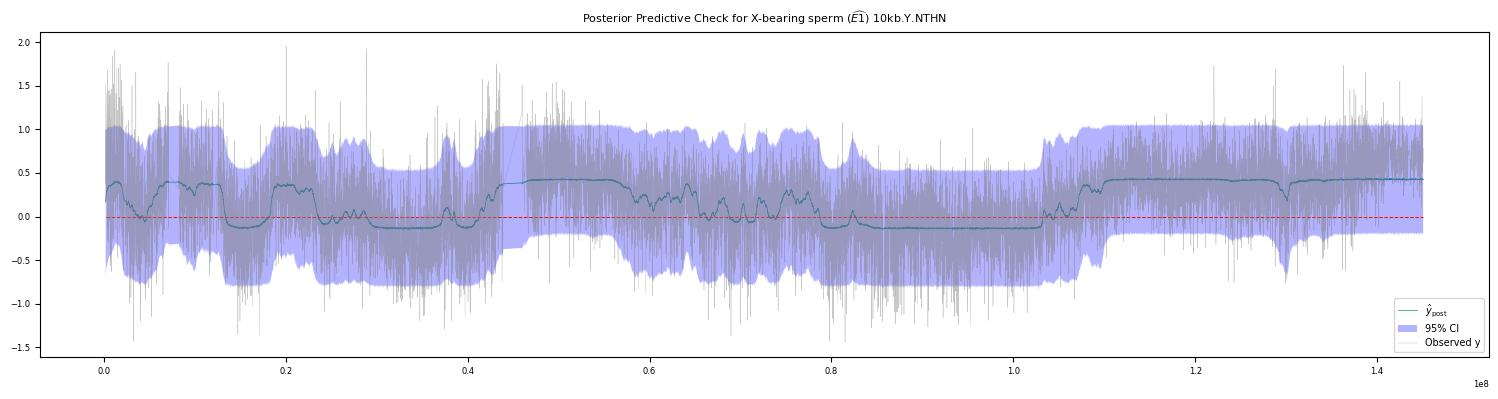

In [26]:
import matplotlib.pyplot as plt
 
for name, trace in traces.items():
    yhat_mean = trace.posterior_predictive.y_hat.mean(dim=('chain', 'draw'))
    yhat_upper = trace.posterior_predictive.y_hat.quantile(0.975, dim=('chain', 'draw'))
    yhat_lower = trace.posterior_predictive.y_hat.quantile(0.025, dim=('chain', 'draw'))

    f,ax = plt.subplots(figsize=(15,4))

    ax.plot(yhat_mean['pos'],yhat_mean, label=r"$\hat{y}_{\mathrm{post}}$", linewidth=0.5)
    ax.hlines(0, min(yhat_mean['pos']), max(yhat_mean['pos']), color='red', linestyle='--', linewidth=0.7)

    ax.fill_between(yhat_mean['pos'], 
                    yhat_upper,
                    yhat_lower,
                    alpha=0.3, label="95% CI", color='blue', ec='None')

    ax.plot(trace.observed_data.y_hat['pos'], trace.observed_data.y_hat, alpha=0.5, color='gray', linewidth=0.3, label="Observed y")

    plt.title("Posterior Predictive Check for X-bearing sperm ($\\widehat{E1}$) " + name)
    plt.legend()
    plt.tight_layout()



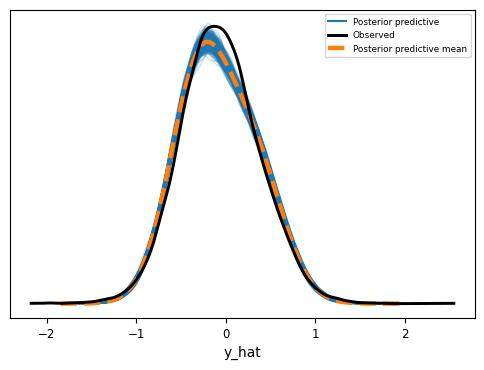

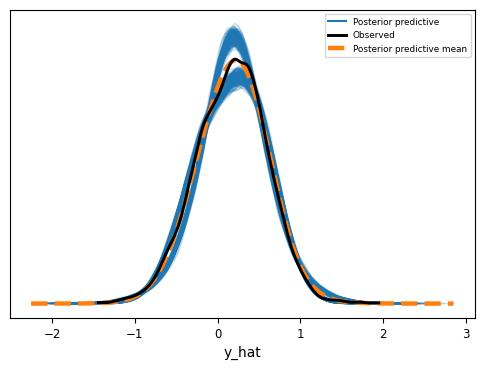

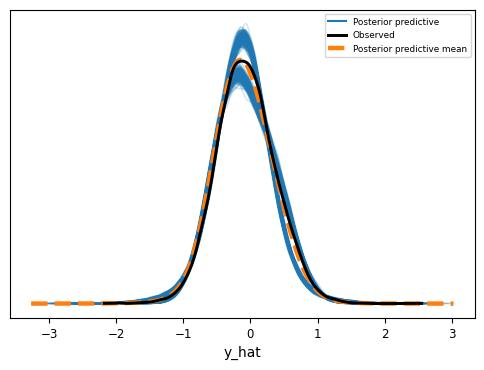

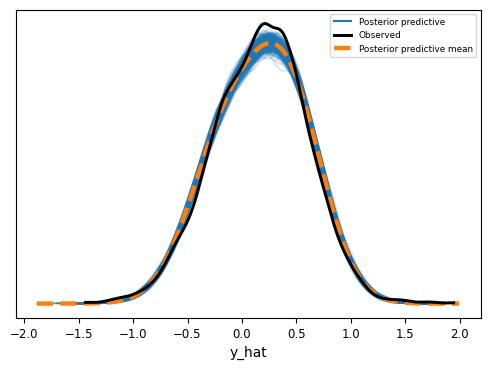

In [27]:
# Plot the posterior predictive check for each model

for name, trace in traces.items():
    az.plot_ppc(trace, figsize=(6,4), num_pp_samples=500)

In [23]:
import numpy as np
import xarray as xr

def count_crossings(w_stack, threshold=0.5):
    # Boolean mask
    above = w_stack > threshold
    above_shifted = above.shift(pos=-1, fill_value=False)

    # Strip last element (to align shapes after shift)
    above = above.isel(pos=slice(0, -1))
    above_shifted = above_shifted.isel(pos=slice(0, -1))

    # Crossings
    cross_up = ((~above) & (above_shifted)).sum(dim="sample")
    cross_down = ((above) & (~above_shifted)).sum(dim="sample")

    # Attach to Dataset
    result = xr.Dataset({
        "cross_up": cross_up,
        "cross_down": cross_down
    })

    return result.to_dataframe()

def compute_ci_intervals(w_stack):
    """
    We need intervals for transition zones; where the data does not fullfill our CI rule:
    Old: ~(1/3 < w_mean < 2/3) => transition zone
    """
    
    ci_upper, ci_lower = w_stack.quantile([0.05, 0.95], dim=("sample"))
    ci_upper = ci_upper.rename("ci_upper")
    ci_lower = ci_lower.rename("ci_lower")
    in_transition = (~((ci_upper <= 1/3) | (ci_upper >= 2/3) | (ci_lower <= 1/3) | (ci_lower >= 2/3)) | ((ci_upper - ci_lower) > 0.5))

    # All True that come in a row is a transition zone, and should have an ID
    starts = in_transition & ~in_transition.shift(pos=1, fill_value=False)

    # Cumulative sum of starts to get unique IDs
    transition_id = starts.cumsum(dim="pos")

    transition_id = transition_id.where(in_transition, drop=True)

    transition_id = transition_id.rename("CI_ID")

    # Convert to DataFrame
    df = transition_id.rename("CI_ID").to_dataframe()

    return df

def get_ci_type(w_mean, df_summarised):
    res = w_mean.pos[1].values - w_mean.pos[0].values  # fixed resolution
    i_before = df_summarised["start"] - res
    i_after = df_summarised["end"] + res
    w_before = w_mean.sel(pos=i_before.values, method='bfill')
    w_after = w_mean.sel(pos=i_after.values, method='ffill')
    sign_before, sign_after = w_before > 0.5, w_after > 0.5

    types = []
    for before, after in zip(sign_before.values, sign_after.values):
    
        if before == after:
            if before > 0:
                types.append("AA")
            else:
                types.append("BA")
        elif before < after:
            types.append("BA")
        else:
            types.append("AB")

    return types
    


In [24]:
def process_trace(name, trace, threshold=0.5):
    """
    Process a single trace to compute summarized crossing data and save intermediate steps.

    Parameters:
        trace: Trace object containing posterior data.
        threshold (float): Threshold for counting crossings.

    Returns:
        dict: A dictionary containing intermediate and final results.
    """
    # Stack into samples
    w_stack = trace.posterior.w.stack(sample=("chain", "draw"))
    count_stack = count_crossings(w_stack, threshold=threshold)
    ci_stack = compute_ci_intervals(w_stack)
    
    # Merge the two DataFrames, join on what's left in ci_stack (in_transition)
    df_merged = ci_stack.merge(count_stack, left_index=True, right_index=True, how="inner")
    df_merged.CI_ID = df_merged.CI_ID.astype(int)
    
    # Count the crossings per CI_ID
    df_summarised = (
        df_merged
        .reset_index()
        .groupby('CI_ID')
        .agg({
            'cross_up': 'sum',
            'cross_down': 'sum',
            'pos': ['min', 'max', 'count']
        })
    )
    df_summarised.columns = ['n_up', 'n_down', 'start', 'end', 'n_bins']
    
    # Assign CI type
    types = get_ci_type(w_stack.mean(dim='sample'), df_summarised)
    df_summarised = df_summarised.assign(type=types)
    
    # Save all intermediate results in a dictionary
    return {
        "name": name,
        "w_stack": w_stack,
        "df_merged": df_merged,
        "df_summarised": df_summarised
    }

def plot_trace_results(data, bin_size=500_000):
    """
    Plot the posterior mean, transition zones, and crossing histograms.

    Parameters:
        data (dict): Dictionary containing `w_stack`, `df_merged`, and `df_summarised`.
        bin_size (int): Size of bins for the histograms.
    """
    w_stack = data["w_stack"]
    df_merged = data["df_merged"]
    df_summarised = data["df_summarised"]

    x = w_stack["pos"]
    y = w_stack.mean(dim=('sample'))

    f, ax = plt.subplots(figsize=(15, 4))
    ax.plot(x, y, label="Posterior mean", color="black", linewidth=0.8)
    ax.fill_between(
        x,
        w_stack.quantile(0.025, dim=("sample")),
        w_stack.quantile(0.975, dim=("sample")),
        alpha=0.3,
        label="95% CI",
        color="blue",
        ec='None'
    )
    ax.axhline(1/3, color="red", linestyle="--", linewidth=0.4, label="Thresholds")
    ax.axhline(2/3, color="red", linestyle="--", linewidth=0.4)

    # Create a vspan for the transition zones
    for i, row in df_summarised.iterrows():
        start = row['start']
        end = row['end']
        color = '0.8'
        label = "Transition zone" if i == 0 else None
        ax.axvspan(start, end, color=color, alpha=0.3, ec='None', label=label)

    # Plot histograms for each CI_ID
    colormap = {
        "BA": "tab:red",
        "AB": "tab:blue",
        "AA": "darkred",
        "BB": "darkblue"
    }
    colors_used = set()
    for cid, group in df_merged.groupby("CI_ID"):
        type = df_summarised.loc[cid, 'type']
        norm_col = 'cross_up' if type == "BA" else 'cross_down'
        
        if type in ('AA', 'BB'):
            # Which column has the most crossings? Chose that
            norm_col = 'cross_up' if group['cross_up'].sum() > group['cross_down'].sum() else 'cross_down'
            
        norm_factor = group[norm_col].sum()
        
        # Normalize so all crossings sum to 1
        norm1 = group[norm_col] / norm_factor
        #norm2 = group['cross_down'] / norm_factor
        
        bins = np.arange(group.index.min(), group.index.max() + bin_size, bin_size)
        
        label1 = f"AB crosses"
        #label2 = f"BA crosses"

        label1 = label if type not in colors_used else None
        #label2 = label if type not in colors_used else None
        colors_used.add(type)
        ax.hist(x=group.index, weights=norm1, color=colormap[type], bins=bins, alpha=0.4, label=label1)
        #ax.hist(x=group.index, weights=norm2, color=colormap[type], bins=bins, alpha=0.4, label=label2)



    ax.set_title(f"Histogram: Each CI is normalized to sum to 1, binsize={bin_size//1000}kb")
    plt.legend()
    plt.suptitle("Posterior Mean with Transition Zones and Crossing Histograms")
    plt.tight_layout()
    plt.show()

Plotting results for 10kb.X.NNHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,
1,1186,256,210000,250000,5,AA
2,814,1466,4170000,4210000,5,AB
3,1403,864,5010000,5050000,5,BA
4,244,712,13570000,13580000,2,AB
5,787,232,18310000,18320000,2,BA
6,736,1083,24100000,24130000,4,AB
7,3357,2390,24840000,24950000,12,BA
8,151,253,30310000,30310000,1,AB
9,1421,540,40320000,40350000,4,BA


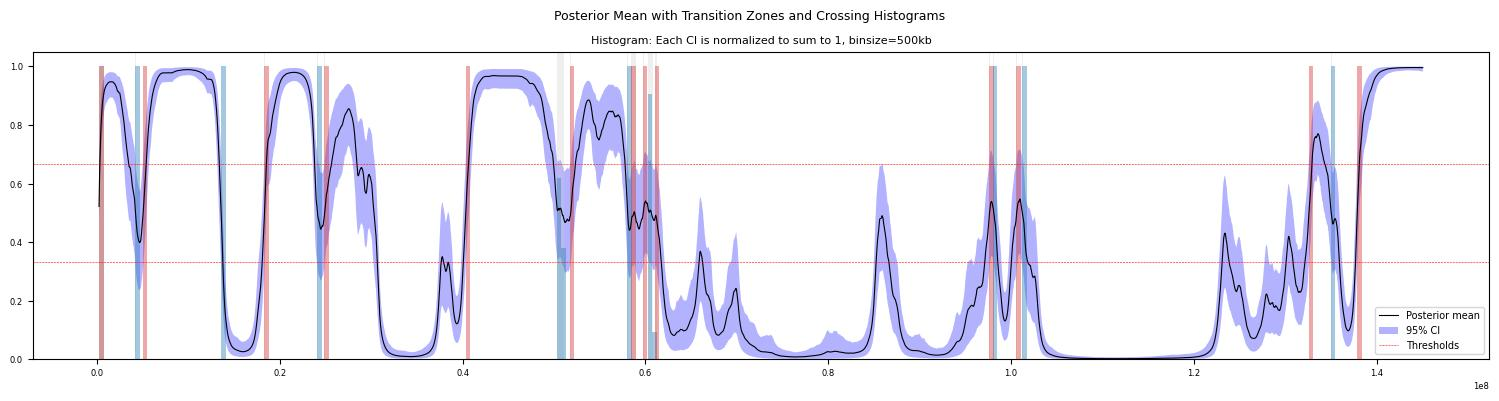

Plotting results for 10kb.Y.NNHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,
1,3537,1793,210000,330000,12,AA


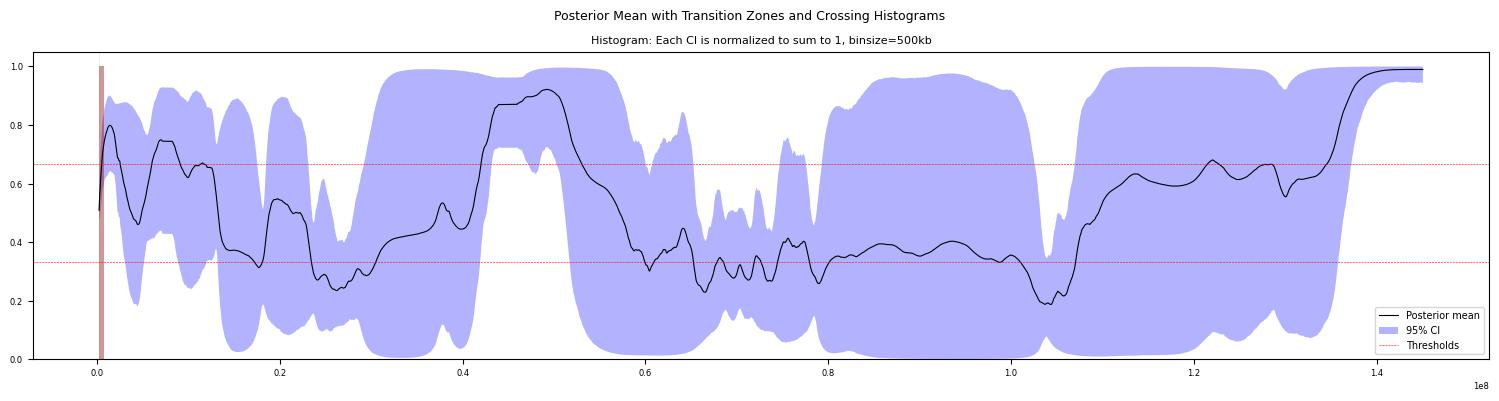

Plotting results for 10kb.X.NTHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,


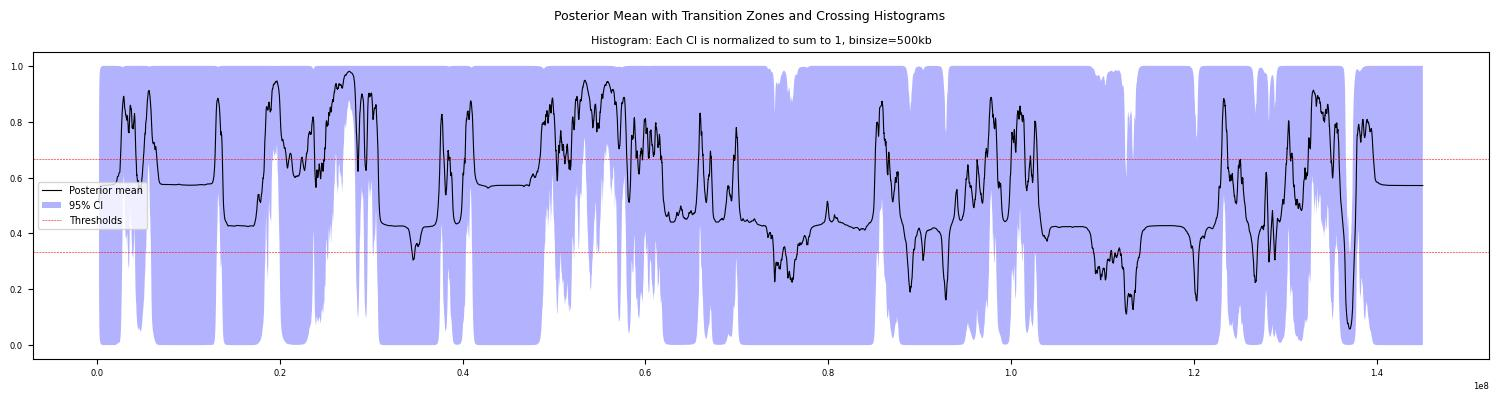

Plotting results for 10kb.Y.NTHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,
1,844,294,210000,210000,1,AA


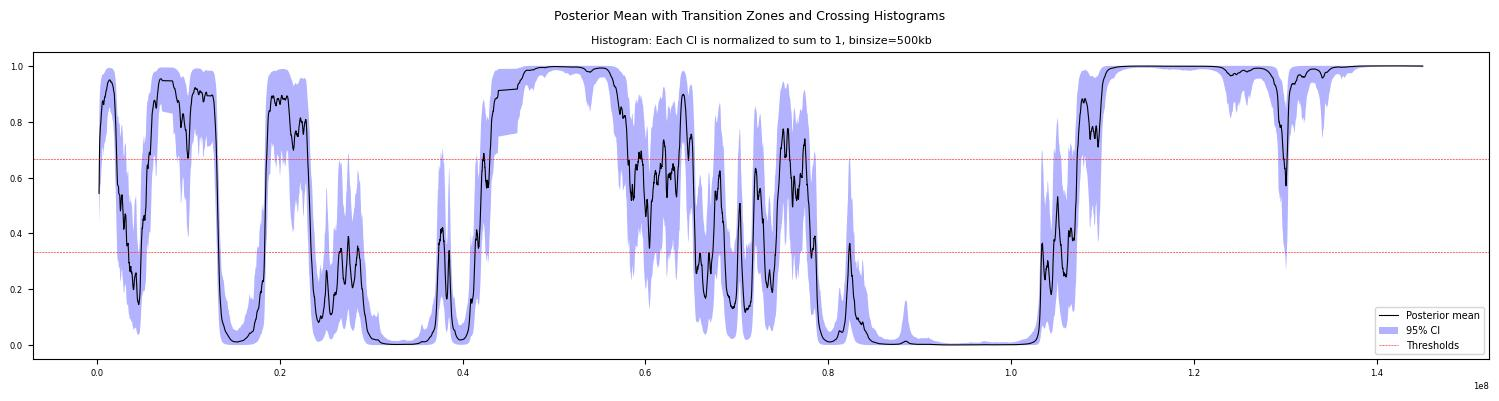

In [25]:
# Process all traces and save results in a dictionary
processed_data = {name: process_trace(name, trace, threshold=0.5) for name, trace in traces.items()}


# Plot results for a specific trace
for name, processed in processed_data.items():
    print(f"Plotting results for {name}")
    display( processed["df_summarised"] )
    plot_trace_results(processed, bin_size=500_000)